In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import joblib

from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from feature_engine.selection import DropConstantFeatures, DropDuplicateFeatures, SmartCorrelatedSelection
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import metrics

In [ ]:
train = pd.read_csv("../../../Data/Dataset-v2/train_B.csv")
val = pd.read_csv("../../../Data/Dataset-v2/val_B.csv")
test = pd.read_csv("../../../Data/Dataset-v2/test_B.csv")

In [3]:
# Separar características y etiquetas para conjunto de entrenamiento
X_train = train.drop(columns=['category'])
y_train = train['category']

# Separar características y etiquetas para conjunto de entrenamiento
X_test = test.drop(columns=['category'])
y_test = test['category']

X_val = val.drop(columns=['category'])
y_val = val['category']

X_train.shape, X_test.shape, X_val.shape

((1117830, 33), (319400, 33), (159690, 33))

## Cell: Hyper-Parameter Search — Random Forest on Reduced Feature Set

Re-runs the same `GridSearchCV` procedure as the baseline, but now on the
**reduced feature set** produced by the three-stage reduction pipeline.

Parameters are identical to the baseline:
- `max_depth`: `[15]`, `cv`: `5`, `scoring`: `'accuracy'`

The best cross-validation accuracy is printed.  Comparing this to the
baseline score quantifies the accuracy impact of the feature reduction.


In [4]:
RF = RandomForestClassifier()

param_grid = {'n_estimators': [15], 'max_depth': [15]} 
grid = GridSearchCV(RF, param_grid, cv=5, scoring='accuracy', return_train_score=True, verbose=1)
grid.fit(X_train, y_train)

print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Cross Validation Score: 0.8312641457108862


## Cell: Reduced-Feature Model Evaluation & Prediction Timing

Evaluates the best Random Forest trained on the **reduced feature set**,
mirroring the full-feature evaluation:

1. **Training score** — Accuracy on the reduced training set.
2. **Test predictions** — `RF.predict(X_test)` on reduced test features.
3. **Test accuracy** — Measured with `accuracy_score`.
4. **Prediction timing** — Wall-clock duration of the `predict` call,
   stored in `elapsed_time`.

> **Key result:** Prediction time should be **lower** than the full-feature
> baseline, since fewer features means fewer split evaluations per tree per sample.


In [5]:
RF =  grid.best_estimator_

y_train_pred = RF.predict(X_train)

start2 = time.time()
y_test_pred = RF.predict(X_test)
stop2 = time.time()


print('Train Accuracy:', accuracy_score(y_train, y_train_pred))
print('Test Accuracy: ', accuracy_score(y_test, y_test_pred))

tiempo2 = stop2 - start2
print(f"Random Forest Test Prediction Time RF: {tiempo2}s")

Train Accuracy: 0.8640598302067398
Test Accuracy:  0.8568096430807765
Random Forest Test Prediction Time RF: 0.5537936687469482s


In [7]:
joblib.dump(RF, 'RF_Multi_v1.pkl')

['RF_Multi_v1.pkl']

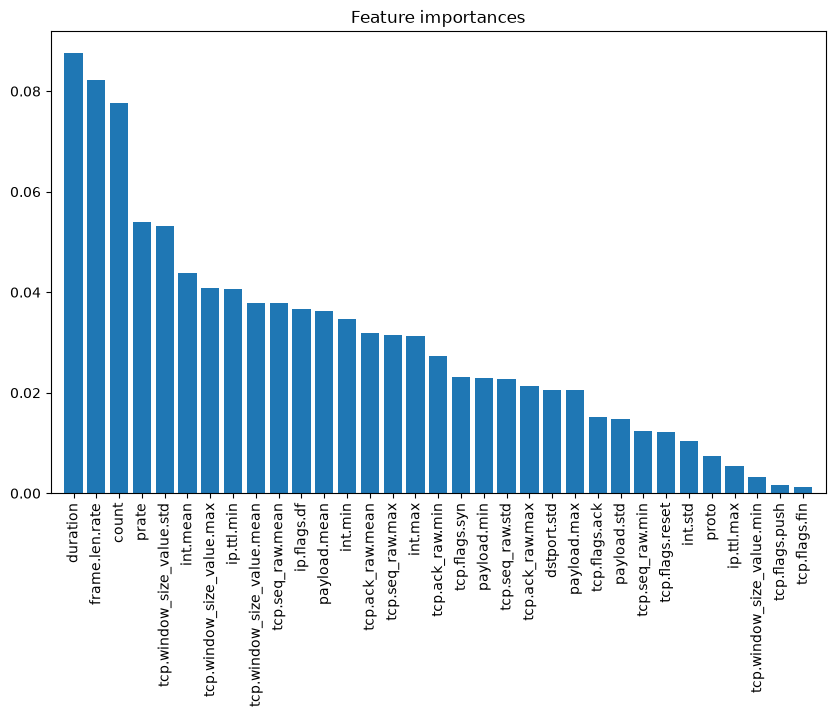

In [8]:
importances = RF.feature_importances_
#plotamos la importancia de las variables
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [9]:
X_train.columns[indices]

Index(['duration', 'frame.len.rate', 'count', 'prate',
       'tcp.window_size_value.std', 'int.mean', 'tcp.window_size_value.max',
       'ip.ttl.min', 'tcp.window_size_value.mean', 'tcp.seq_raw.mean',
       'ip.flags.df', 'payload.mean', 'int.min', 'tcp.ack_raw.mean',
       'tcp.seq_raw.max', 'int.max', 'tcp.ack_raw.min', 'tcp.flags.syn',
       'payload.min', 'tcp.seq_raw.std', 'tcp.ack_raw.max', 'dstport.std',
       'payload.max', 'tcp.flags.ack', 'payload.std', 'tcp.seq_raw.min',
       'tcp.flags.reset', 'int.std', 'proto', 'ip.ttl.max',
       'tcp.window_size_value.min', 'tcp.flags.push', 'tcp.flags.fin'],
      dtype='str')

This is done to reduce computational cost and to make a comparison between RF and SVMs / QSVMs with the same number of features. This is because QSVMs cmputational cost scales exponentially with the number of features.

In [10]:
RF = RandomForestClassifier(n_estimators=15, max_depth=15)

sel = SelectFromModel(RF, threshold=0.0285)
sel.fit(X_train, y_train)

,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",RandomForestC...estimators=15)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",0.0285
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1
,"max_features max_features: int, callable, default=NoneThe maximum number of features to select.- If an integer, then it specifies the maximum number of features to allow.- If a callable, then it specifies how to calculate the maximum number of features allowed. The callable will receive `X` as input: `max_features(X)`.- If `None`, then all features are kept.To only select based on ``max_features``, set ``threshold=-np.inf``... versionadded:: 0.20.. versionchanged:: 1.1 `max_features` accepts a callable.",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a ``coef_``attribute or ``feature_importances_`` attribute of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"estimator_ estimator_: estimatorThe base estimator from which the transformer is built. This attributeexist only when `fit` has been called.- If `prefit=True`, it is a deep copy of `estimator`.- If `prefit=False`, it is a clone of `estimator` and fit on the data passed to `fit` or `partial_fit`.",RandomForestClassifier,RandomForestC...estimators=15)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](33,)","['dstport.std','frame.len.rate','ip.flags.df',...,'payload.max', 'payload.mean','proto']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,33
threshold_ threshold_: floatThe threshold value used for feature selection.,float,0.0285


In [11]:
# this command let's me visualise those features that were selected.

# sklearn will select those features which importance values
# are greater than the mean of all the coefficients.

sel.get_support()

array([False,  True,  True, False, False, False,  True, False, False,
        True, False,  True, False,  True, False, False, False,  True,
       False,  True, False, False,  True, False,  True,  True,  True,
        True, False,  True, False, False, False])

In [12]:
# let's make a list and count the selected features
selected_feat = X_train.columns[(sel.get_support())]

len(selected_feat)

if "proto" not in selected_feat:
    selected_feat = selected_feat.append(pd.Index(["proto"]))
    
X_train = X_train[selected_feat]
X_val = X_val[selected_feat]
X_test = X_test[selected_feat]

In [13]:
X_train.shape, X_test.shape, X_val.shape

((1117830, 15), (319400, 15), (159690, 15))

In [14]:
RF = RandomForestClassifier()

param_grid = {'n_estimators': [15], 'max_depth': [15]} 
grid = GridSearchCV(RF, param_grid, cv=5, scoring='accuracy', return_train_score=True, verbose=1)
grid.fit(X_train, y_train)

print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Cross Validation Score: 0.8019842015333281


Acuracy only goes downs by 3% after the dataset was reduced from 33 features to 15.

In [15]:
RF =  grid.best_estimator_

y_train_pred = RF.predict(X_train)

start2 = time.time()
y_test_pred = RF.predict(X_test)
stop2 = time.time()


print('Train Accuracy:', accuracy_score(y_train, y_train_pred))
print('Test Accuracy: ', accuracy_score(y_test, y_test_pred))

tiempo2 = stop2 - start2
print(f"Random Forest Test Prediction Time RF: {tiempo2}s")

Train Accuracy: 0.830830269361173
Test Accuracy:  0.8233750782717596
Random Forest Test Prediction Time RF: 0.4951643943786621s


Analyse briefly these results (From the confusion mtrix to the FAR & FRR curves)

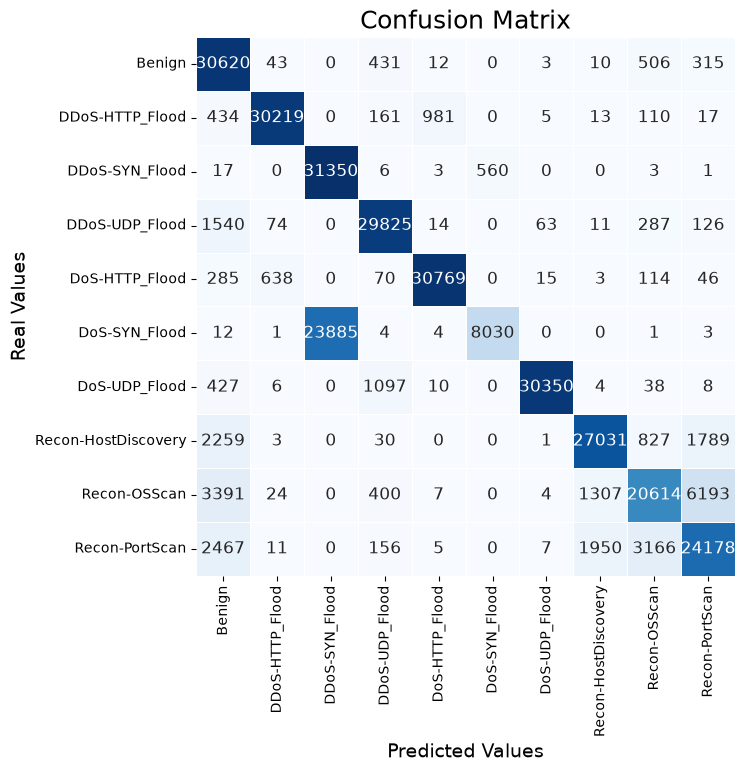

In [20]:
cm = metrics.confusion_matrix(y_test, y_test_pred)
normalized_matrix = cm

class_names = ['Benign', 'DDoS-HTTP_Flood', 'DDoS-SYN_Flood', 'DDoS-UDP_Flood', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-UDP_Flood', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PortScan']

# Plot
sns.heatmap(
    normalized_matrix, 
    annot=True, 
    fmt='0.0f', 
    linewidth=0.5,
    annot_kws={"size": 12}, 
    xticklabels=class_names,
    yticklabels=class_names, 
    square=True, 
    cmap='Blues', 
    cbar=False
)

fig = plt.gcf()
fig.set_size_inches(7, 7)
plt.ylabel('Real Values', fontsize=14)
plt.xlabel('Predicted Values', fontsize=14)
plt.title('Confusion Matrix', fontsize=18)

# Guardar como PDF (¡hazlo antes del plt.show!)
plt.savefig('CM_RF_33car_10Class.pdf', format='pdf', bbox_inches='tight')

plt.show()


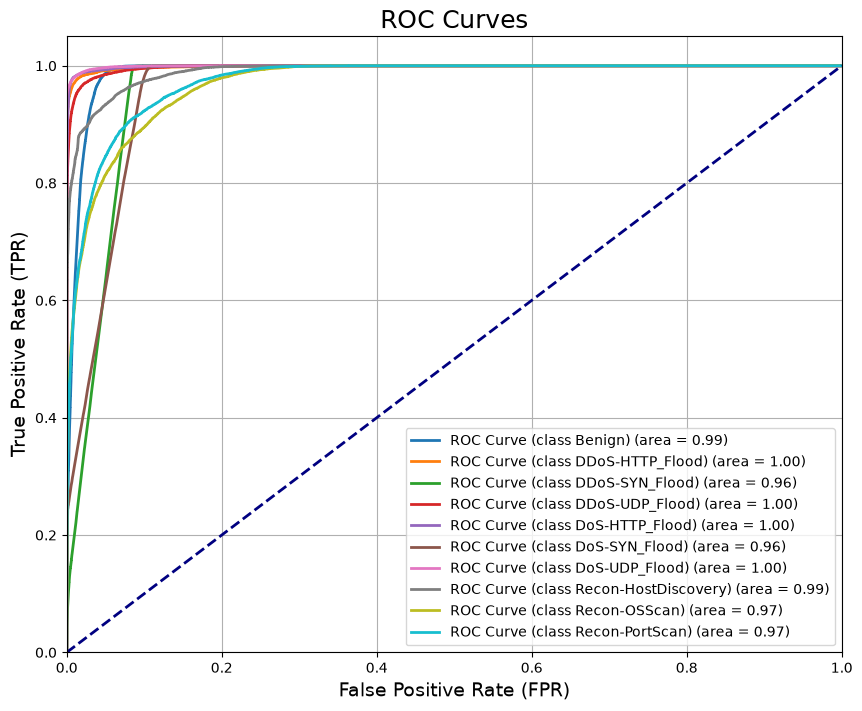

In [22]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = RF.predict_proba(X_test)

# Binarizar las etiquetas
from sklearn.preprocessing import label_binarize
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i, class_label in enumerate(classes):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(10, 8))
for class_label in classes:
    plt.plot(fpr[class_label], tpr[class_label], lw=2,
             label=f'ROC Curve (class {class_label}) (area = {roc_auc[class_label]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC Curves', fontsize=18)
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('ROC_RF_33car_10Class.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [23]:
y_pred_prob = RF.predict_proba(X_test)

genuinos = []
impostores = []

for i in range(len(y_test)):

    etiqueta_real = y_test[i]
    indice_genuino = np.where(RF.classes_ == etiqueta_real)[0][0]
    score_genuino = y_pred_prob[i][indice_genuino]
    scores_impostores = np.delete(y_pred_prob[i], indice_genuino)
    genuinos.append(score_genuino)
    impostores.extend(scores_impostores)

genuinos = np.array(genuinos)
impostores = np.array(impostores)

print("Genuines:", genuinos.shape)
print("Impostors:", impostores.shape)

Genuines: (319400,)
Impostors: (2874600,)


In [24]:
thresholds = np.arange(-0.001, 1.001, 0.001)
FAR = []
FRR = []
for threshold in thresholds:
    FAR.append(np.sum(impostores >= threshold) / len(impostores))
    FRR.append(np.sum(genuinos <= threshold) / len(genuinos))

# Imprimir FAR, FRR
print("FAR:", FAR)
print("FRR:", FRR)

FAR: [np.float64(1.0), np.float64(1.0), np.float64(0.23149690391706673), np.float64(0.21616642315452586), np.float64(0.20416301398455436), np.float64(0.1969414875113059), np.float64(0.18987511305920823), np.float64(0.1844781882696723), np.float64(0.18034091699714744), np.float64(0.17636575523551104), np.float64(0.17245286300702706), np.float64(0.16823697210046615), np.float64(0.16414944687956584), np.float64(0.160729840673485), np.float64(0.1571735197940583), np.float64(0.15419327906491337), np.float64(0.1511674667779865), np.float64(0.14829263201836776), np.float64(0.14592221526473248), np.float64(0.14373965073401518), np.float64(0.14180268559103876), np.float64(0.13978431781813122), np.float64(0.13790092534613513), np.float64(0.1360391010923259), np.float64(0.13414422876226256), np.float64(0.13242329367564182), np.float64(0.13060077923885063), np.float64(0.12884575245251514), np.float64(0.12734049954776316), np.float64(0.12584985737146037), np.float64(0.12446879565852641), np.float64

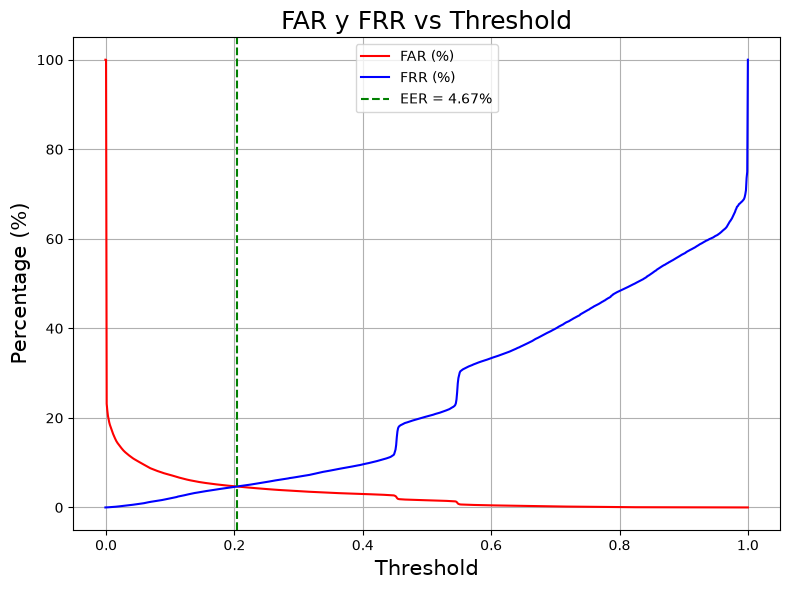

In [33]:
FAR_porcentaje = np.array(FAR) * 100
FRR_porcentaje = np.array(FRR) * 100

# Calcular EER
eer_threshold_index = np.nanargmin(np.abs(FAR_porcentaje - FRR_porcentaje))
eer_threshold = thresholds[eer_threshold_index]
eer = FAR_porcentaje[eer_threshold_index]

plt.figure(figsize=(8, 6))
plt.plot(thresholds, FAR_porcentaje, label='FAR (%)', color='red')
plt.plot(thresholds, FRR_porcentaje, label='FRR (%)', color='blue')
plt.axvline(eer_threshold, color='green', linestyle='--', label=f'EER = {eer:.2f}%')

plt.xlabel('Threshold', fontsize=15)
plt.ylabel('Percentage (%)', fontsize=15)
plt.title('FAR y FRR vs Threshold', fontsize=18)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('FAR_FRR_RF_10CLASS.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [27]:
import joblib
joblib.dump(RF, 'RF_Multi_v2.pkl')

['RF_Multi_v2.pkl']

In [28]:
X_train = pd.DataFrame(X_train, columns=selected_feat)
X_val = pd.DataFrame(X_val, columns=selected_feat)
X_test = pd.DataFrame(X_test, columns=selected_feat)

In [29]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
train = pd.concat([X_train, y_train], axis=1)

X_val_reducido = X_val.reset_index(drop=True)
y_val_reducido = y_val.reset_index(drop=True)
val = pd.concat([X_val_reducido, y_val_reducido], axis=1)

X_test_reducido = X_test.reset_index(drop=True)
y_test_reducido = y_test.reset_index(drop=True)
test = pd.concat([X_test_reducido, y_test_reducido], axis=1)


In [32]:
train.to_csv('../../../Dataset-Files/Dataset-v3/train_C.csv', index=False)
test.to_csv('../../../Dataset-Files/Dataset-v3/test_C.csv', index=False)
val.to_csv('../../../Dataset-Files/Dataset-v3/val_C.csv', index=False)